Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Kidney/cellProportion_12methods_4x3.pdf /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Kidney/cellProportion_12methods_4x3.svg


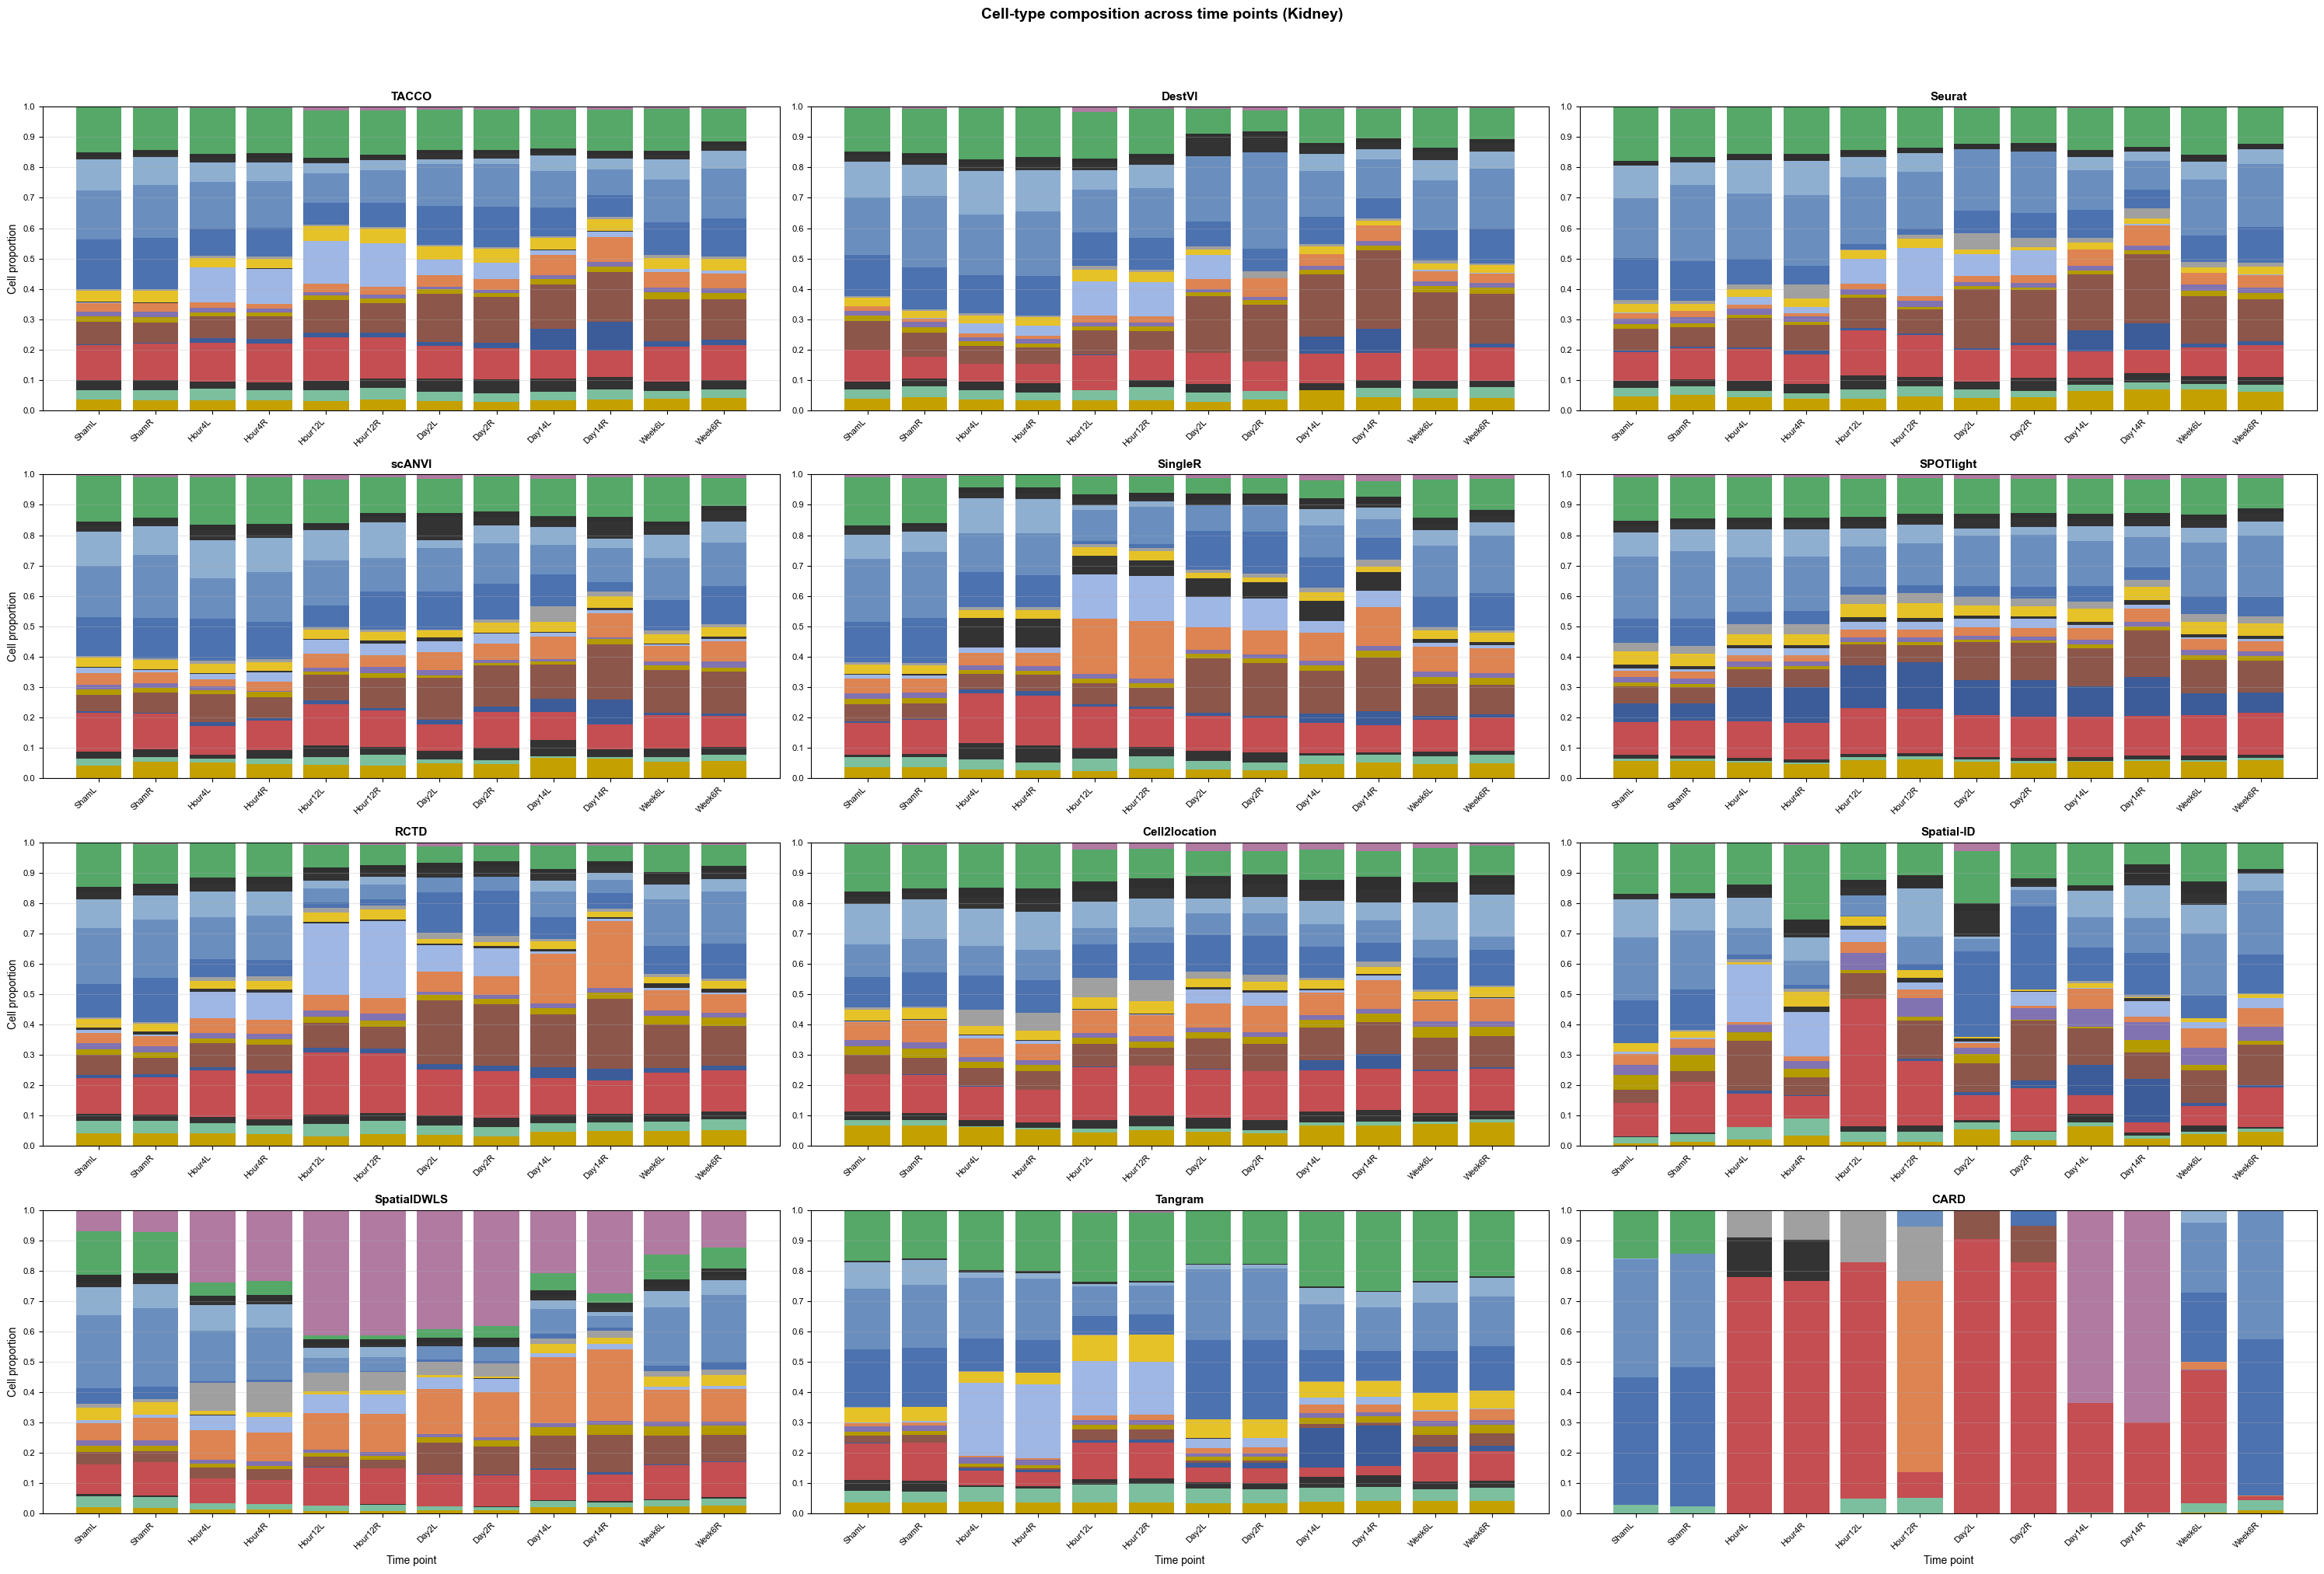

In [8]:
import os
import pandas as pd
cell_colors = {
    # 🟦 Proximal tubule (PT) family – blue gradient
    'PTS1':  '#4C72B0',
    'PTS2':  '#6A8FBF',
    'PTS3':  '#8FAFD1',
    'FR_PT': '#3B5C99',   # filtered reabsorption PT – deeper blue
    'Inj_PT':'#9FB7E5',   # injured PT – pale desaturated blue

    # 🟩 Loop of Henle / distal tubule – green gradient
    'TAL':  '#55A868',
    'DCT':  '#7CBF9E',
    'DTL':  '#3E8F6E',    # descending thin limb – darker green

    # 🟨 Collecting duct – olive / yellow-green
    'CNT':  '#C4A000',
    'PC':   '#E6C229',
    'ICA':  '#B39B00',   # intercalated A – darker olive
    'ICB':  '#8172B2',   # intercalated B – purple (kept distinct)

    # 🟥 Vascular / stromal – red / brown
    'EC':       '#C44E52',
    'Glom-EC':  '#A63D40',  # glomerular EC – deeper red
    'Per-SMC':  '#7A3E3E',  # pericyte / SMC – dark maroon
    'Fib':      '#8C564B',

    # 🟧 Immune – orange
    'Immune': '#DD8452',

    # ⚫ Specialized renal cells – neutral / distinct
    'Pod': '#2F2F2F',
    'PEC': '#A0A0A0',
    'Uro': '#B07AA1'
}
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["text.usetex"] = False
mpl.rcParams["pdf.use14corefonts"] = False
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "Arial"
METHOD_PANELS = [
    ("TACCO", "tacco"),
    ("DestVI", "DestVI"),
    ("Seurat", "Seurat"),
    ("scANVI", "scVI"),
    ("SingleR", "SingleR"),
    ("SPOTlight", "spotlight"),
    ("RCTD", "RCTD"),
    ("Cell2location", "cell2location"),
    ("Spatial-ID", "spatialID"),
    ("SpatialDWLS", "spatialDWLS"),
    ("Tangram", "Tangram"),
    ("CARD", "CARD"),
]

section_order = [
    "ShamL",
    "ShamR",
    "Hour4L",
    "Hour4R",
    "Hour12L",
    "Hour12R",
    "Day2L",
    "Day2R",
    "Day14L",
    "Day14R",
    "Week6L",
    "Week6R",
]

base = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer"


def pivot_for_method(folder_key):
    all_props = []
    for tp in section_order:
        csv = f"{base}/{folder_key}/Kidney_output/{tp}_cell_label.csv"
        if not os.path.isfile(csv):
            continue
        df = pd.read_csv(csv, index_col=0)
        vc = df["y_pred"].value_counts(normalize=True).reset_index()
        vc.columns = ["cell_type", "proportion"]
        prop = vc
        prop["section"] = tp
        all_props.append(prop)
    if not all_props:
        return None
    prop_df = pd.concat(all_props, ignore_index=True)
    return (
        prop_df.pivot(index="section", columns="cell_type", values="proportion")
        .fillna(0)
        .reindex(section_order)
    )


fig, axes = plt.subplots(4, 3, figsize=(30, 20), sharey=True)
axes = axes.ravel()
_yticks = [i * 0.1 for i in range(11)]

for idx, (disp_name, folder_key) in enumerate(METHOD_PANELS):
    ax = axes[idx]
    pivot_df = pivot_for_method(folder_key)
    if pivot_df is None or pivot_df.empty:
        ax.text(
            0.5,
            0.5,
            f"No data\n({folder_key})",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=10,
        )
        ax.set_title(disp_name, fontsize=11, fontweight="bold")
        continue

    stack_order = sorted(pivot_df.columns)
    pivot_df = pivot_df[stack_order]
    bottom = pd.Series([0] * len(pivot_df), index=pivot_df.index)
    for cell in stack_order:
        ax.bar(
            pivot_df.index,
            pivot_df[cell],
            bottom=bottom,
            color=cell_colors.get(cell, "#333333"),
            width=0.8,
        )
        bottom += pivot_df[cell]

    ax.set_title(disp_name, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(range(len(pivot_df.index)))
    ax.set_xticklabels(list(pivot_df.index), rotation=45, ha="right", fontsize=8)

    row, col = idx // 3, idx % 3
    if col == 0:
        ax.set_ylabel("Cell proportion", fontsize=10)
    if row == 3:
        ax.set_xlabel("Time point", fontsize=10)

for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_yticks(_yticks)
    ax.tick_params(axis="y", labelleft=True, labelsize=8)

fig.suptitle("Cell-type composition across time points (Kidney)", fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout(rect=[0, 0, 1, 0.98])
out_pdf = f"{base}/metric/Kidney/cellProportion_12methods_4x3.pdf"
out_svg = f"{base}/metric/Kidney/cellProportion_12methods_4x3.svg"
os.makedirs(os.path.dirname(out_pdf), exist_ok=True)
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.savefig(out_svg, format="svg", bbox_inches="tight")
print("Saved:", out_pdf, out_svg)
plt.show()

In [5]:
cell_colors = {
    # 🟦 Proximal tubule (PT) family – blue gradient
    'PTS1':  '#4C72B0',
    'PTS2':  '#6A8FBF',
    'PTS3':  '#8FAFD1',
    'FR_PT': '#3B5C99',   # filtered reabsorption PT – deeper blue
    'Inj_PT':'#9FB7E5',   # injured PT – pale desaturated blue

    # 🟩 Loop of Henle / distal tubule – green gradient
    'TAL':  '#55A868',
    'DCT':  '#7CBF9E',
    'DTL':  '#3E8F6E',    # descending thin limb – darker green

    # 🟨 Collecting duct – olive / yellow-green
    'CNT':  '#C4A000',
    'PC':   '#E6C229',
    'ICA':  '#B39B00',   # intercalated A – darker olive
    'ICB':  '#8172B2',   # intercalated B – purple (kept distinct)

    # 🟥 Vascular / stromal – red / brown
    'EC':       '#C44E52',
    'Glom-EC':  '#A63D40',  # glomerular EC – deeper red
    'Per-SMC':  '#7A3E3E',  # pericyte / SMC – dark maroon
    'Fib':      '#8C564B',

    # 🟧 Immune – orange
    'Immune': '#DD8452',

    # ⚫ Specialized renal cells – neutral / distinct
    'Pod': '#2F2F2F',
    'PEC': '#A0A0A0',
    'Uro': '#B07AA1'
}

In [2]:
import scanpy as sc 
adata = sc.read_h5ad('/maiziezhou_lab2/yuling/datasets/Kidney/Xenium.h5ad')
adata.obs 

,x_centroid,y_centroid,n_genes,n_counts,ident,region,celltype_plot,time,CN
ShamL_1,1189.500888,1174.337585,33,76,ShamL,Cortex,PTS1,Sham,CN2: Cortical Proximal Tubule
ShamL_2,1186.349110,1186.872309,29,77,ShamL,Cortex,PTS1,Sham,CN2: Cortical Proximal Tubule
ShamL_3,1154.533530,1212.770802,19,24,ShamL,Cortex,Immune,Sham,CN1: Glomerular Niche
ShamL_4,1203.117995,1171.406309,42,205,ShamL,Cortex,PTS1,Sham,CN2: Cortical Proximal Tubule
ShamL_5,1143.585521,1232.370928,7,9,ShamL,Cortex,EC,Sham,CN2: Cortical Proximal Tubule
...,...,...,...,...,...,...,...,...,...
Week6R_146821,500.060816,3704.812281,15,17,Week6R,Cortex,Fib,Week6,CN1: Glomerular Niche
Week6R_147127,2940.096672,2137.234444,11,11,Week6R,Cortex,PTS2,Week6,CN2: Cortical Proximal Tubule
Week6R_147130,858.506358,4257.601085,5,10,Week6R,Cortex,Fib,Week6,CN2: Cortical Proximal Tubule
Week6R_147467,3225.293707,1728.360497,9,10,Week6R,Cortex,EC,Week6,CN1: Glomerular Niche


/tmp/ipykernel_3630063/2539964537.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')


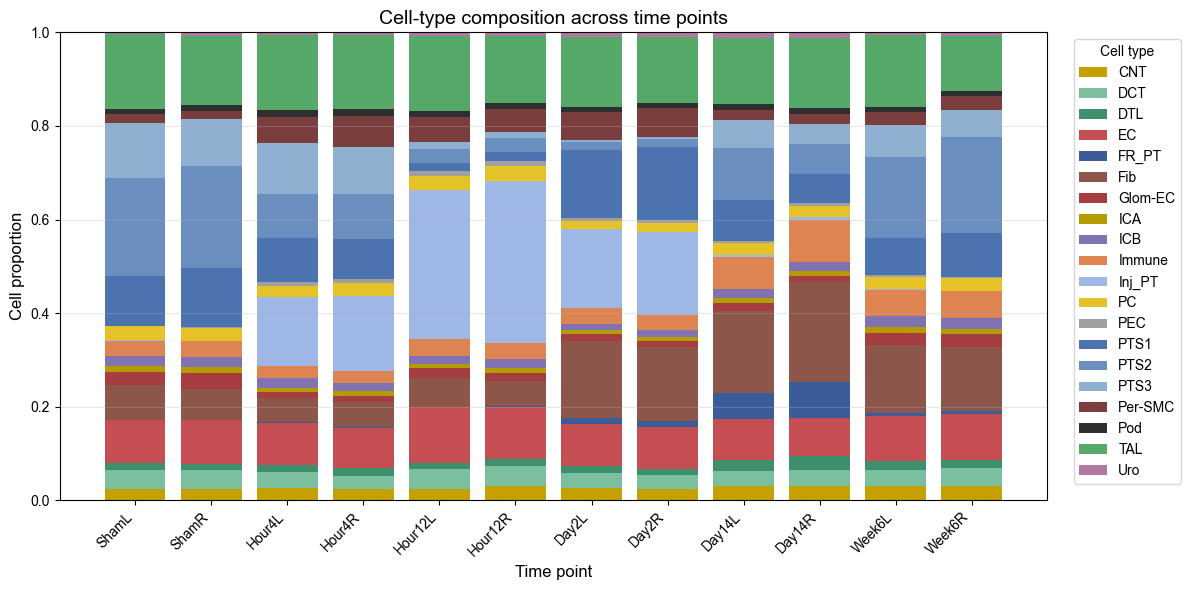

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import pandas as pd 
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'  
df = adata.obs[['celltype_plot','ident']]
section_order = [
'ShamL','ShamR','Hour4L','Hour4R','Hour12L','Hour12R',
'Day2L','Day2R','Day14L','Day14R','Week6L','Week6R'
]
all_props = []
for csv in section_order:
    ds = adata[adata.obs['ident'] ==csv, ]
    df = ds.obs[['celltype_plot']]
    timepoint = csv

    prop = (
        df['celltype_plot']
        .value_counts(normalize=True)
        .reset_index()
        .rename(columns={'index': 'cell_type', 'celltype_plot': 'proportion'})
    )

    prop['section'] = timepoint
    all_props.append(prop)

prop_df = pd.concat(all_props, ignore_index=True)
prop_df.columns = ['cell_type', 'proportion', 'section']

pivot_df = (
    prop_df
    .pivot(index='section', columns='cell_type', values='proportion')
    .fillna(0)
    .reindex(section_order)
)

# Same stack order as the 12-panel cell: alphabetical cell_type name
# (sorted columns — e.g. ICB before TAL), not dict insertion order.
stack_order = sorted(pivot_df.columns)
pivot_df = pivot_df[stack_order]

fig, ax = plt.subplots(figsize=(12, 6))

bottom = pd.Series([0] * len(pivot_df), index=pivot_df.index)

for cell in stack_order:
    ax.bar(
        pivot_df.index,
        pivot_df[cell],
        bottom=bottom,
        color=cell_colors.get(cell, '#333333'),
        label=cell,
        width=0.8
    )
    bottom += pivot_df[cell]

ax.set_ylabel('Cell proportion', fontsize=12)
ax.set_xlabel('Time point', fontsize=12)
ax.set_ylim(0, 1)
ax.set_title(f'Cell-type composition across time points', fontsize=14)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title='Cell type'
)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Kidney/cellProportion_0420.pdf", format="pdf", bbox_inches="tight")
plt.show()